In [3]:
from src.utils import get_data_env
from src.UPDATED_dataloading import EpiConfig, DataOrchestrator
from src.UPDATED_models import PersistenceModel, NodeRFModel, NodeLSTMModel
from src.UPDATED_dataloading import GraphDataLoaderManager, ShallowDataLoaderManager

from src.UPDATED_models import GATv2Model

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 1
sequence_length = 1
lags            = 1

config = EpiConfig(
    disease             = 'influenza',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lags                = lags,
    nuts_level          = nuts_level,
    log_transform       = True,
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest
    )    

dataorchestrator    = (DataOrchestrator(config).build())

In [4]:
n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

shallowdata        = ShallowDataLoaderManager(dataorchestrator).construct_dataloaders()
graphdataloader_id  = GraphDataLoaderManager(dataorchestrator).retrieve_graph('identity_graph').construct_dataloaders()



==                     lstm                     ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.3895, val loss: 0.5374 ✓ (new best)
Epoch 2 train loss: 0.3629, val loss: 0.4695 ✓ (new best)
Epoch 3 train loss: 0.3445, val loss: 0.4230 ✓ (new best)
Epoch 4 train loss: 0.3230, val loss: 0.3843 ✓ (new best)
Epoch 5 train loss: 0.2893, val loss: 0.3188 ✓ (new best)
Epoch 6 train loss: 0.2512, val loss: 0.2815 ✓ (new best)
Epoch 7 train loss: 0.2372, val loss: 0.2765 ✓ (new best)
Epoch 8 train loss: 0.2324, val loss: 0.2850 (patience: 1/20)
Epoch 9 train loss: 0.2306, val loss: 0.2749 ✓ (new best)
Epoch 10 train loss: 0.2267, val loss: 0.2661 ✓ (new best)
Epoch 11 train loss: 0.2249, val loss: 0.2667 (patience: 1/20)
Epoch 12 train loss: 0.2234, val loss: 0.2599 ✓ (new best)
Epoch 13 train loss: 0.2225, val loss: 0.2667 (patience: 1/20)
Epoch 14 train loss: 0.2209, val loss: 0.2612 (patience: 2/20)
Epoch 15 train l

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 583.21it/s]

Test loss: 0.4089


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

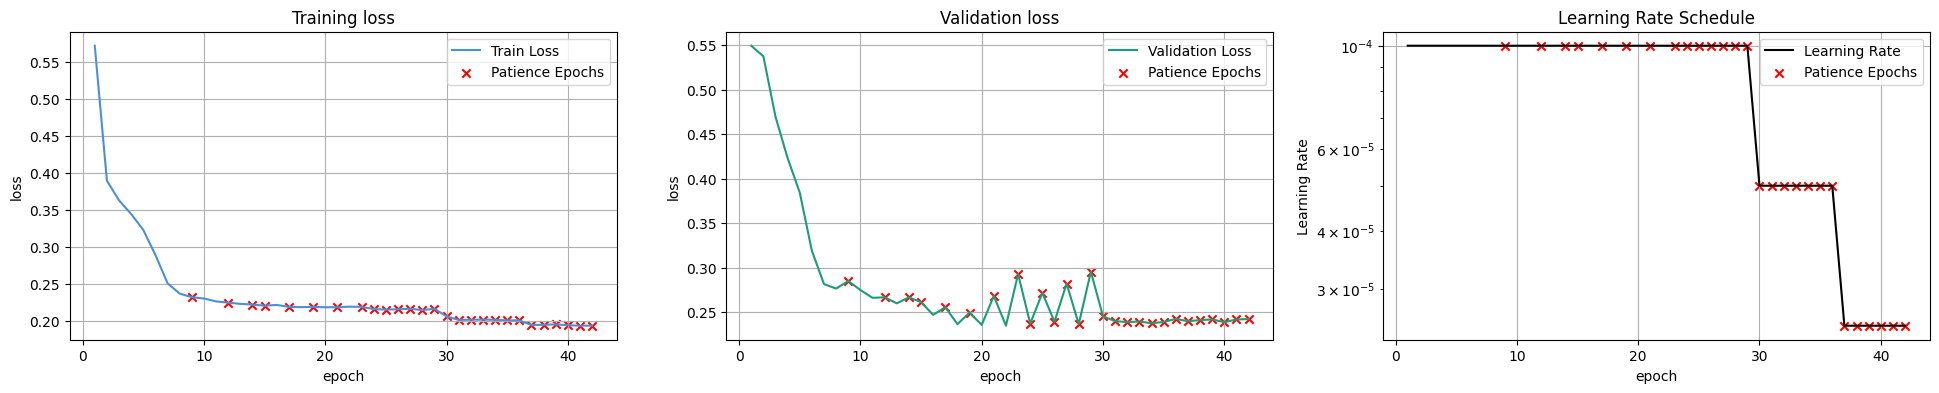

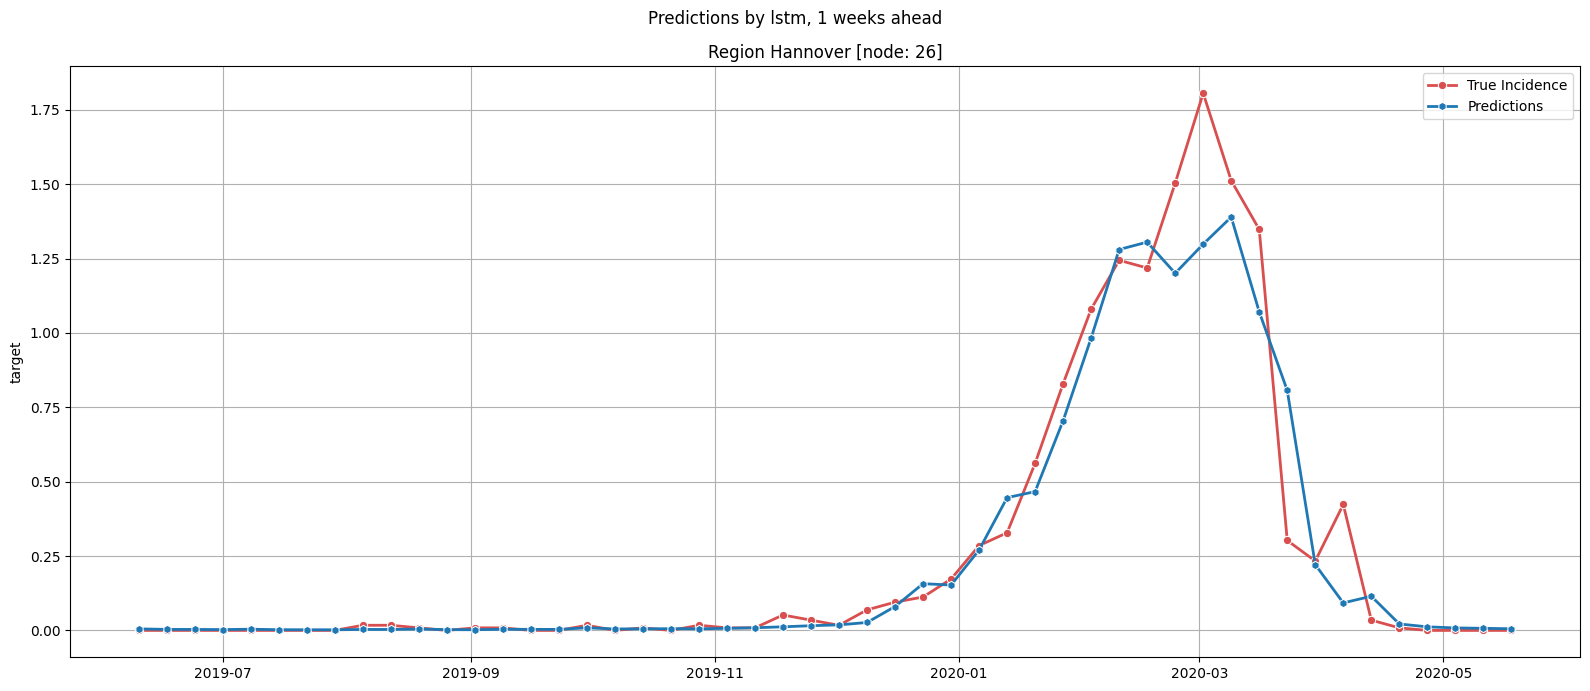

In [5]:
lstm = NodeLSTMModel(graphdataloader_id, name = 'lstm')
lstm.set_model_hparams(hidden_size=128)
lstm.set_global_hparams(**global_hparams)
lstm.train(verbose = 2)
lstm.forecast('test')
lstm.show_forecasts(26)

In [6]:
persistence = PersistenceModel(shallowdata)
persistence.forecast('test')

PersistenceModel(name='Persistence Model')

In [10]:
from src.UPDATED_evaluation.evaluator import Evaluator
e = Evaluator([persistence, lstm])
e.add_evaluation(0)

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  3.02it/s]


/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


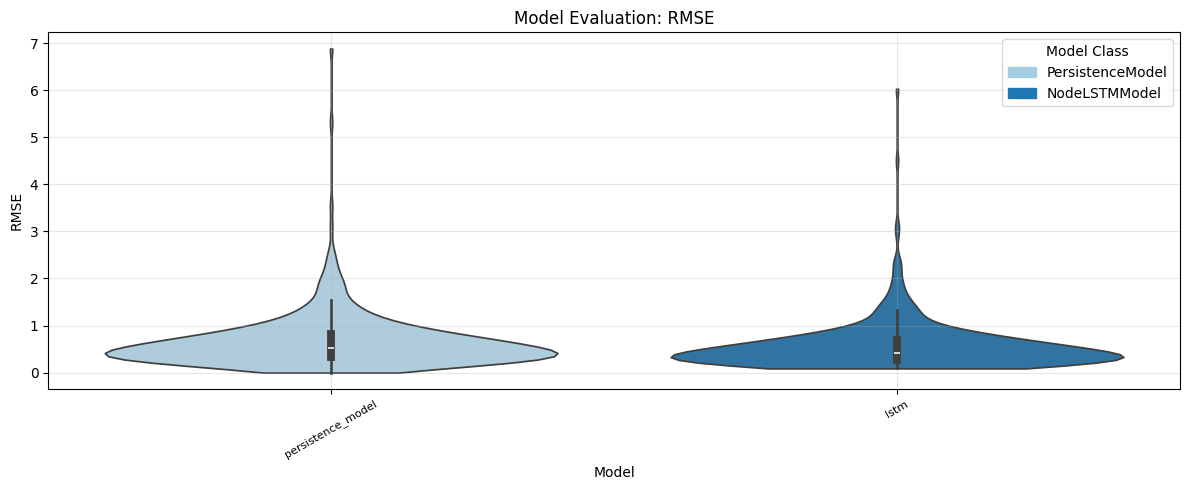

In [16]:
e.plotter.plot_metric('rmse', 'horizon_0')